In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

C:\Users\chris\AppData\Local\Temp\ipykernel_79664\48179419.py:27: LicenceNotice:


Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence



In [2]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionStructure import STIRFutureOptionStructure
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

In [3]:
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

In [46]:
as_of = datetime.date(2026, 5, 29)
# as_of = "live"

q = STIRFutureOptionQuery(
    structure=STIRFutureOptionStructure.OUTRIGHT,
    value=STIRFutureOptionValue.PRICE,
    symbol="SFRZ26|ATMS",  
    market_request={
        "endpoint": "option_snapshot",
        "timestamp": as_of,
        "use_ql_calculator": True,
        # "force_refresh": True,
    },
)

req = q.build_mdp_request(as_of)
pr = stirfo_mdp.get_pricer(req)

package, weights = q.resolve_package(pricer_or_curve=pr)
value_map = q.build_value_map(
    pricer_or_curve=pr,
    package=package,
    risk_weights=weights,
)

print("resolved_symbol:", package[0].symbol())
print("price:", value_map.apply(STIRFutureOptionValue.PRICE))
print("iv_normal_bps:", value_map.apply(STIRFutureOptionValue.IV_NORMAL_BPS))
print("delta:", value_map.apply(STIRFutureOptionValue.DELTA))
print("gamma:", value_map.apply(STIRFutureOptionValue.GAMMA))
print("vega:", value_map.apply(STIRFutureOptionValue.VEGA))
print("theta:", value_map.apply(STIRFutureOptionValue.THETA))

resolved_symbol: SFRZ26|9625S
price: 0.405
iv_normal_bps: 69.81540816147704
delta: -0.12180145914855484
gamma: 1.510148123324507
vega: 0.5661441989337423
theta: -0.35294957196860993


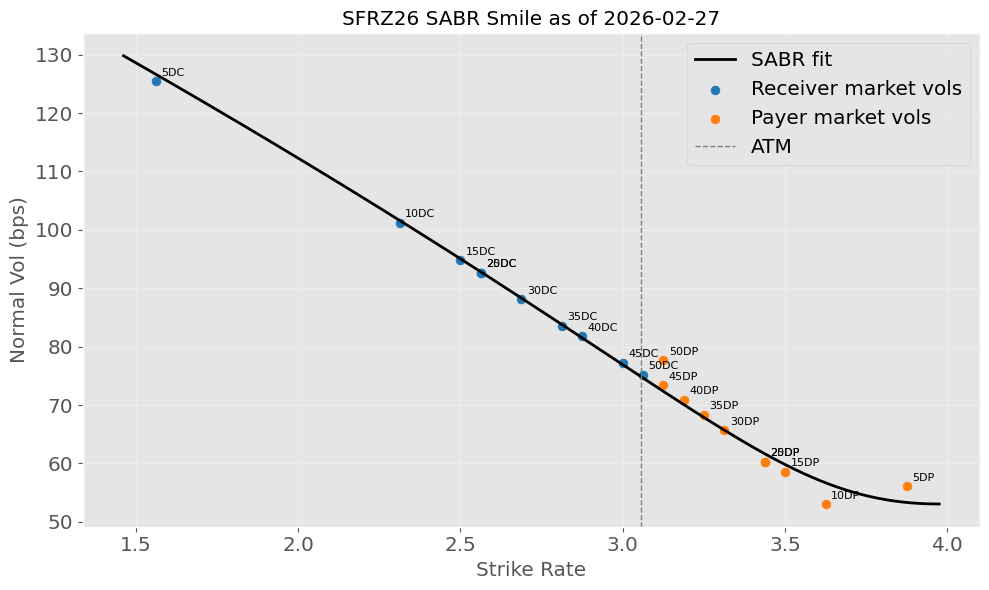

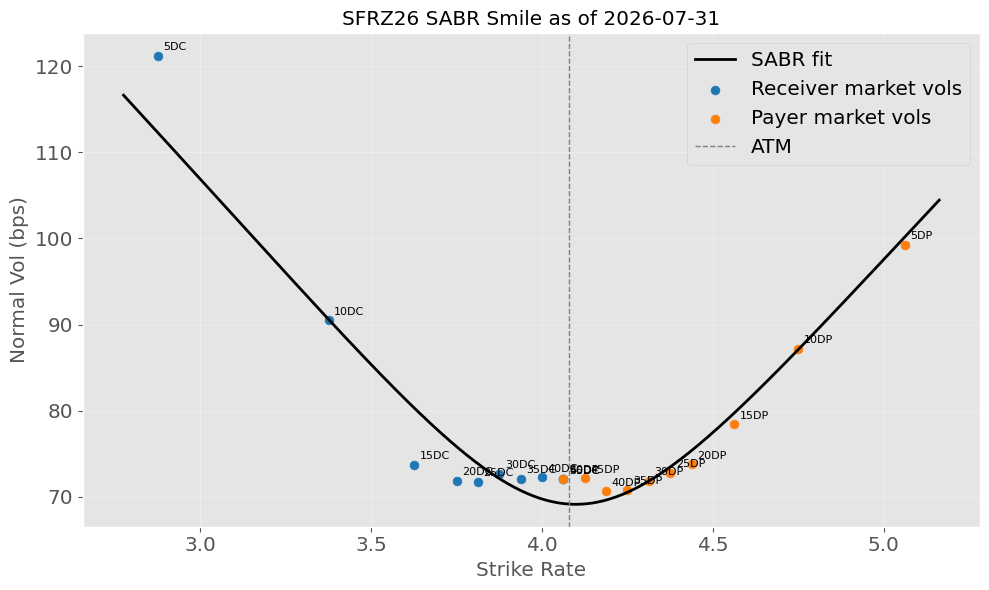

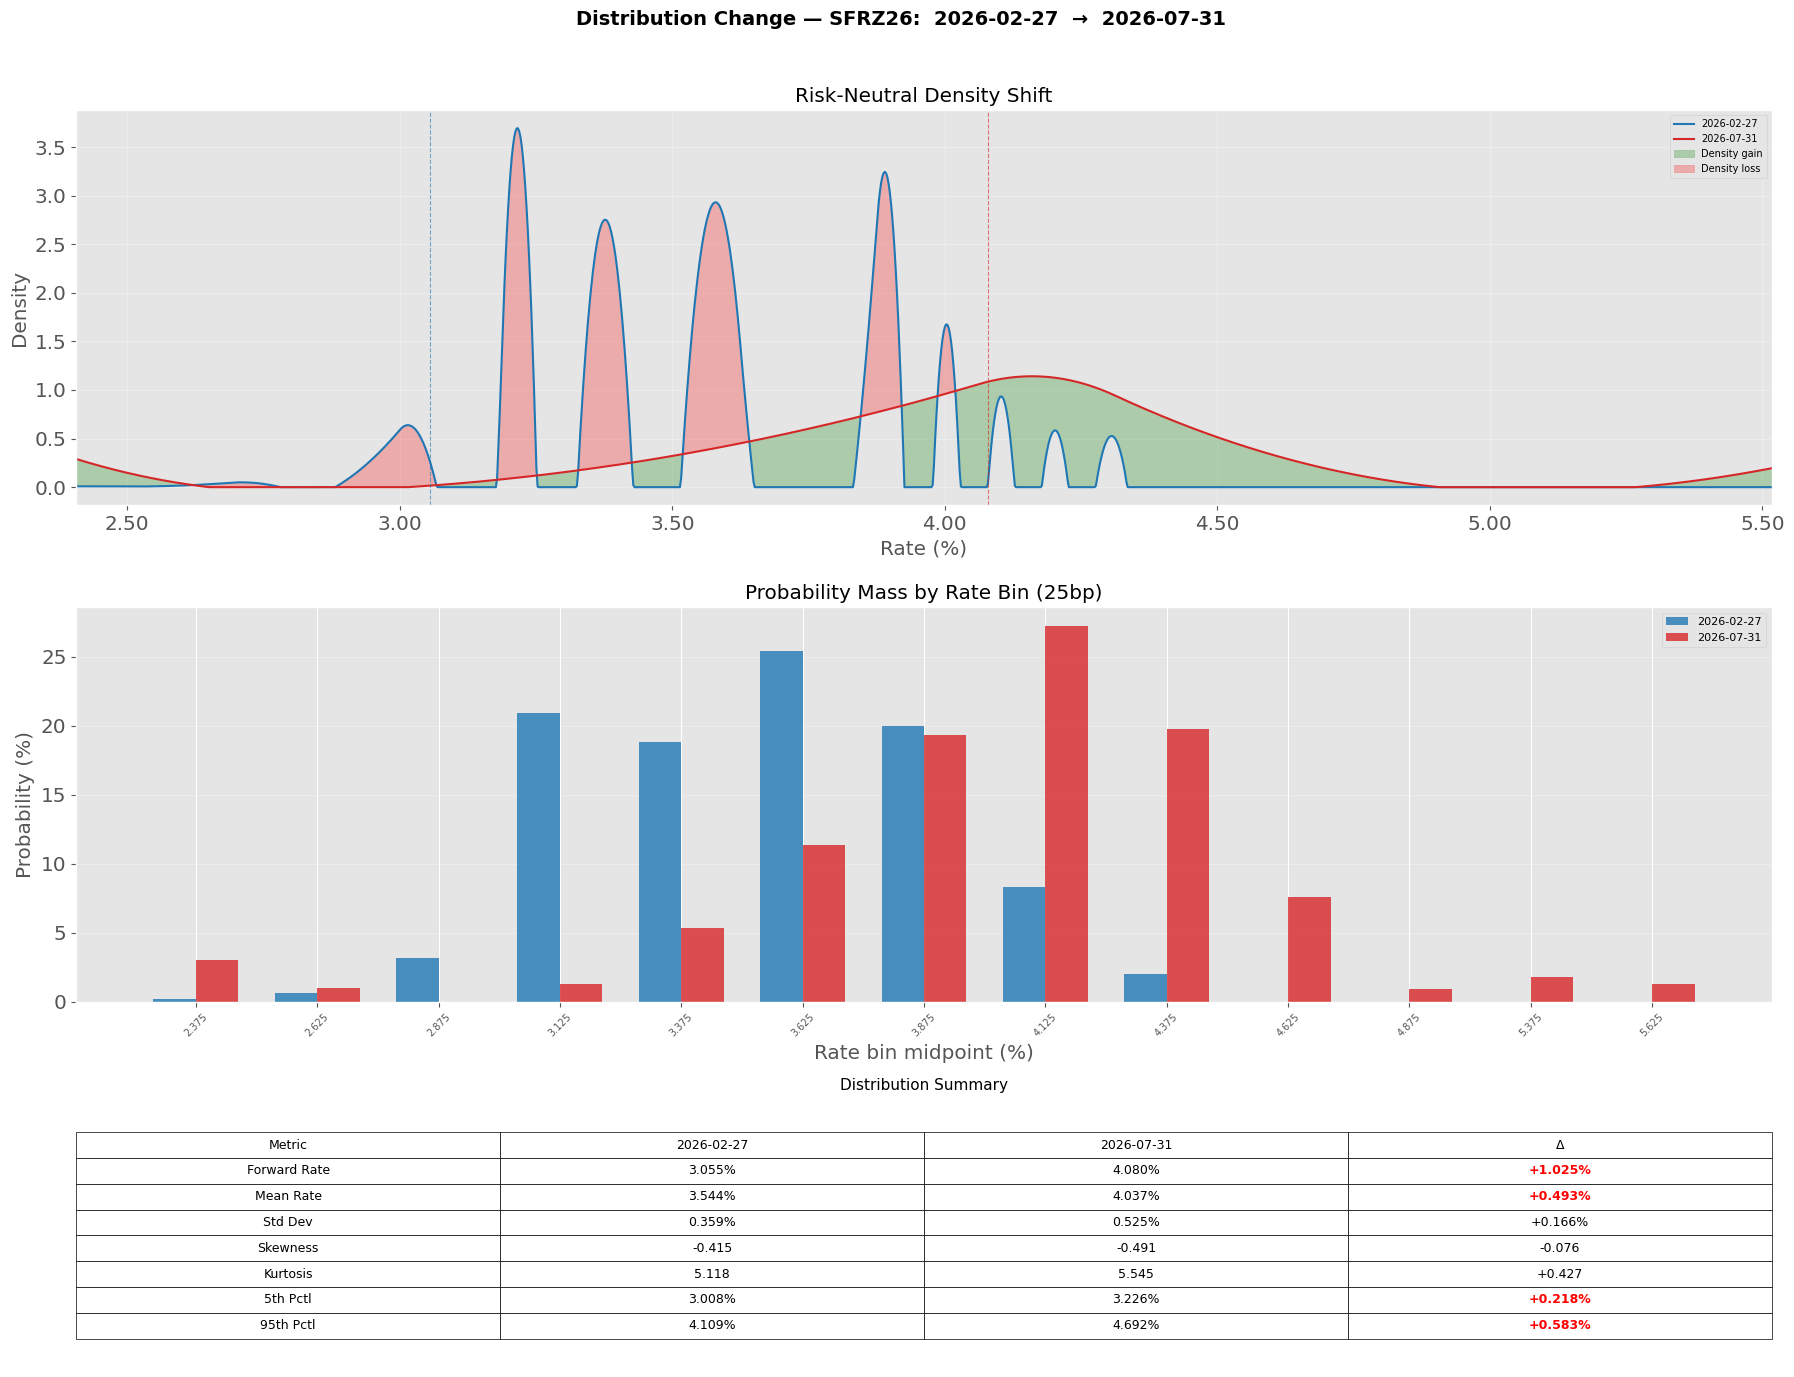

In [5]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
	plot_distribution_change,
	resolve_strip_symbols,
    plot_strip_distribution_change,
    plot_sfr_smile
)


# config = FedScenarioConfig.default_sofr_scenarios(
#     current_rate=3.64, n_cuts_range=[-1, 0, 1, 2, 3]
# )
# dist = SFRImpliedDistribution(scenario_config=config)
dist = SFRImpliedDistribution()

smile1 = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 2, 27),
    # "strike_offsets_bps": "listed",
    # "force_refresh": True,
    "show_tqdm": True,
})
plot_sfr_smile(smile1)

smile2 = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 7, 31),
    # "as_of": "live", 
    # "strike_offsets_bps": "listed",
    "show_tqdm": True,
})
plot_sfr_smile(smile2)

snap_before, snap_after = dist.compare(smile1, smile2)
fig = plot_distribution_change(snap_before, snap_after)

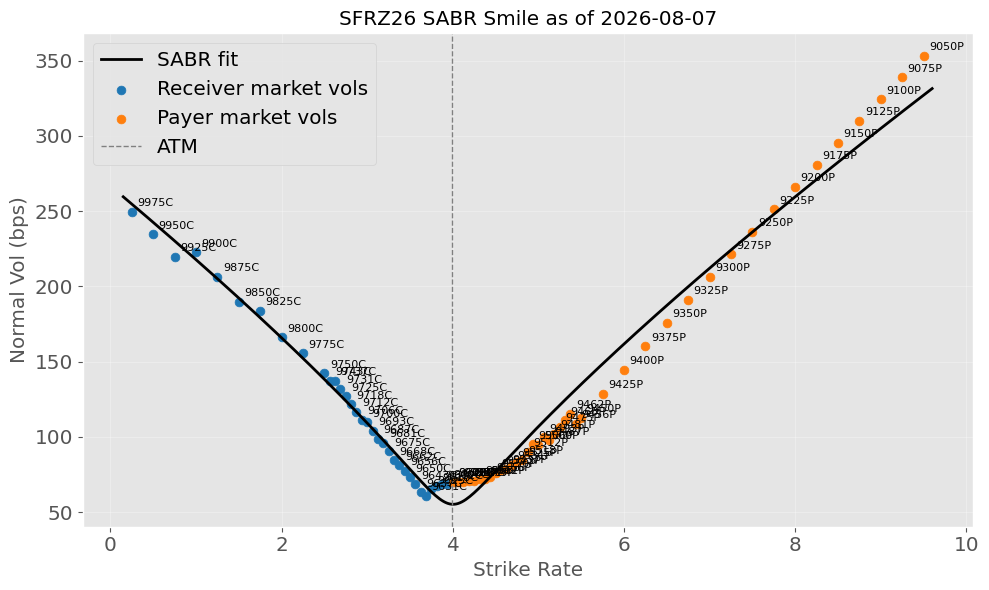

mean: 4.003438403390707
median: 3.969730991311454
5th: 3.5023710410688738
95th: 4.675392183817957
bin edges: [ 0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.    3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75
  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75
  9.    9.25  9.5   9.75 10.  ]
bin probabilities: [9.95000844e-04 8.43400264e-04 7.38463876e-04 6.85682020e-04
 6.85064982e-04 7.36603051e-04 8.40295688e-04 9.96159984e-04
 1.20417571e-03 1.46434280e-03 1.77666334e-03 9.85374601e-04
 5.77722211e-04 3.66035023e-02 2.58531027e-01 2.13185623e-01
 2.40179744e-01 1.44248803e-01 5.50002381e-02 1.86622577e-02
 1.02727391e-02 4.86235495e-03 1.34353350e-03 1.50445829e-05
 0.00000000e+00 0.00000000e+00 5.39758476e-05 1.80919112e-04
 2.65051236e-04 3.04073769e-04 2.97996003e-04 2.46815962e-04
 1.50524112e-04 2.54445724e-05 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.11409371e-05 7.26183182e-04 2.30405862e-03]


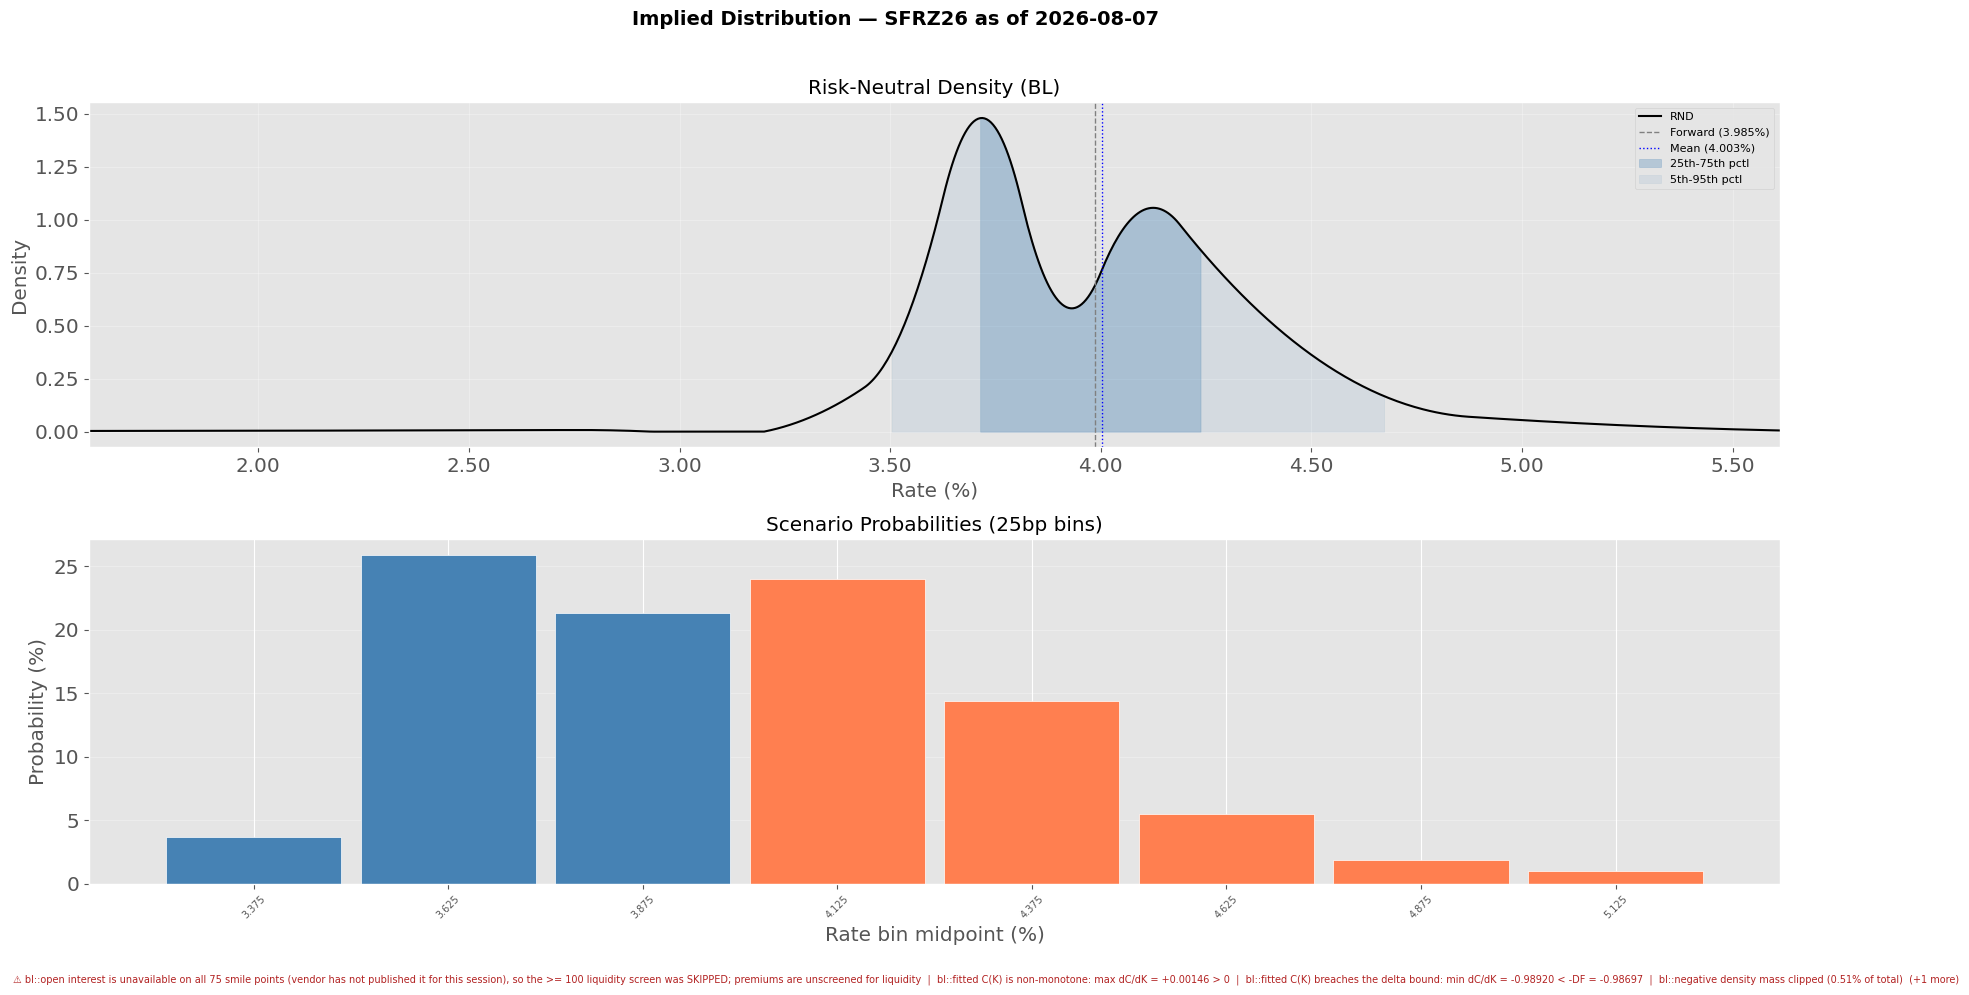

In [8]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
	plot_distribution_change,
	resolve_strip_symbols,
    plot_strip_distribution_change,
    plot_sfr_smile
)

smile = stirfo_mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 8, 7),
    # "as_of": "live",
    "strike_offsets_bps": "listed",
    # "show_tqdm": True,
})
plot_sfr_smile(smile)

# Default is raw JPM-style BL:
# observed OTM premiums, OI >= 100, put-call parity, 25bp bins
dist = SFRImpliedDistribution()

snapshot = dist.extract(smile)
bl = snapshot.bl_result

print("mean:", bl.mean_rate)
print("median:", bl.percentile(50))
print("5th:", bl.percentile(5))
print("95th:", bl.percentile(95))
print("bin edges:", bl.bin_edges_rate)
print("bin probabilities:", bl.bin_probabilities)

a = plot_snapshot_dashboard(snapshot)

In [42]:
bl.percentile(95)

4.6151735072297395